Loaded fold 0 factor library (frozen, train-derived):
  L1 factors : 44
  L2 factors : 29

Fold 0 partitions:
  Train   : 12,537 firms  |  risky_upgrade rate: 8.73%
  Holdout : 3,163 firms  |  risky_upgrade rate: 7.33%

[Setup] Applying fixed (train-derived) factor library to both partitions...

  [TRAIN] N=12,537  L1/firm mean=14.6  L2/firm mean=5.0  Total/firm mean=19.6

  [HOLDOUT] N=3,163  L1/firm mean=14.7  L2/firm mean=5.2  Total/firm mean=20.0

  Baseline DR — train   : 8.73%  (N_default=1094)
  Baseline DR — holdout : 7.33%  (N_default=232)

  Saved: NB07_01_firm_level_warnings_fold0_TRAIN.csv
  Saved: NB07_01_firm_level_warnings_fold0_HOLDOUT.csv

Q1: Default rate by total warning count — Fold 0, TRAIN vs HOLDOUT
                       n_firms_train  default_rate_train  lift_train  n_firms_holdout  default_rate_holdout  lift_holdout
warning_count_bracket                                                                                                    
0                       

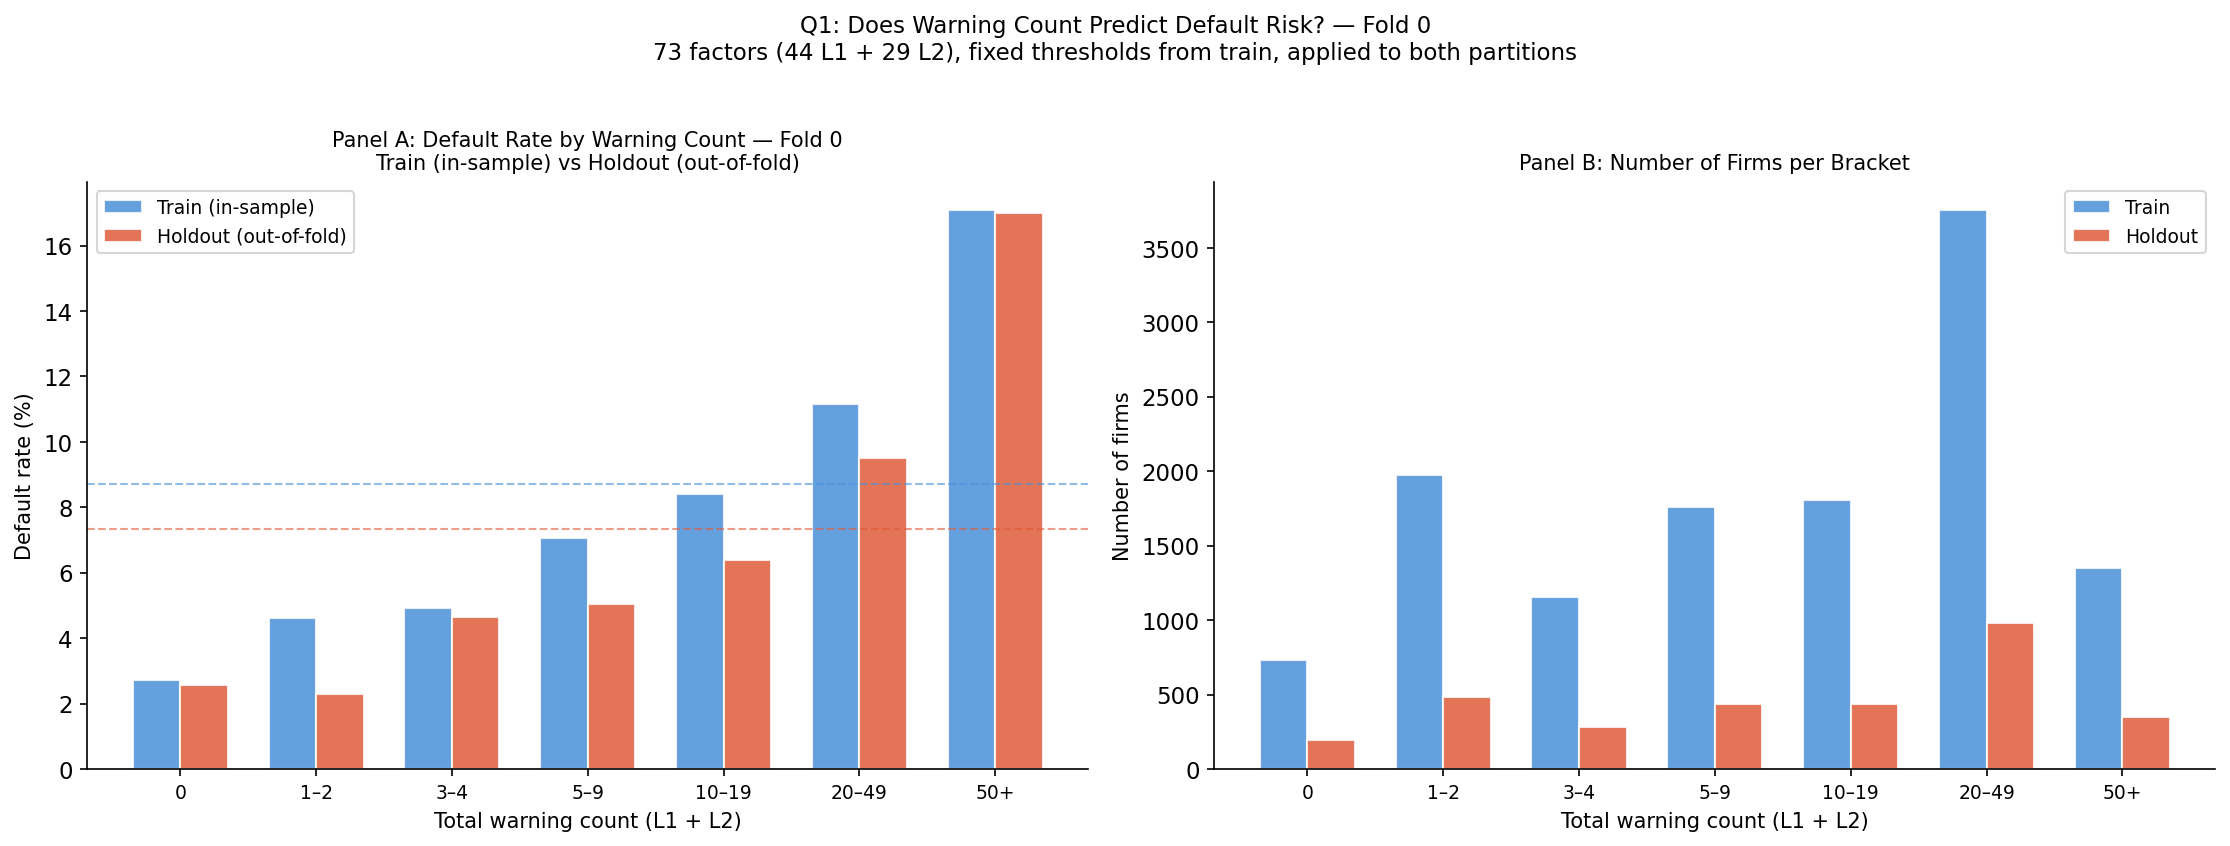

Figure saved: NB07_Q1_train_vs_holdout_fold0.png

Q3: Coverage-precision trade-off — Fold 0, TRAIN vs HOLDOUT
                   n_flagged_train  coverage_train  warn_rate_train  precision_train  lift_train  n_flagged_holdout  coverage_holdout  warn_rate_holdout  precision_holdout  lift_holdout
warning_threshold                                                                                                                                                                        
1                             1074          0.9817           0.9416           0.0910       1.043                227            0.9784             0.9387             0.0765         1.042
3                              983          0.8985           0.7842           0.1000       1.146                216            0.9310             0.7860             0.0869         1.185
5                              926          0.8464           0.6918           0.1068       1.224                203            0.8750             

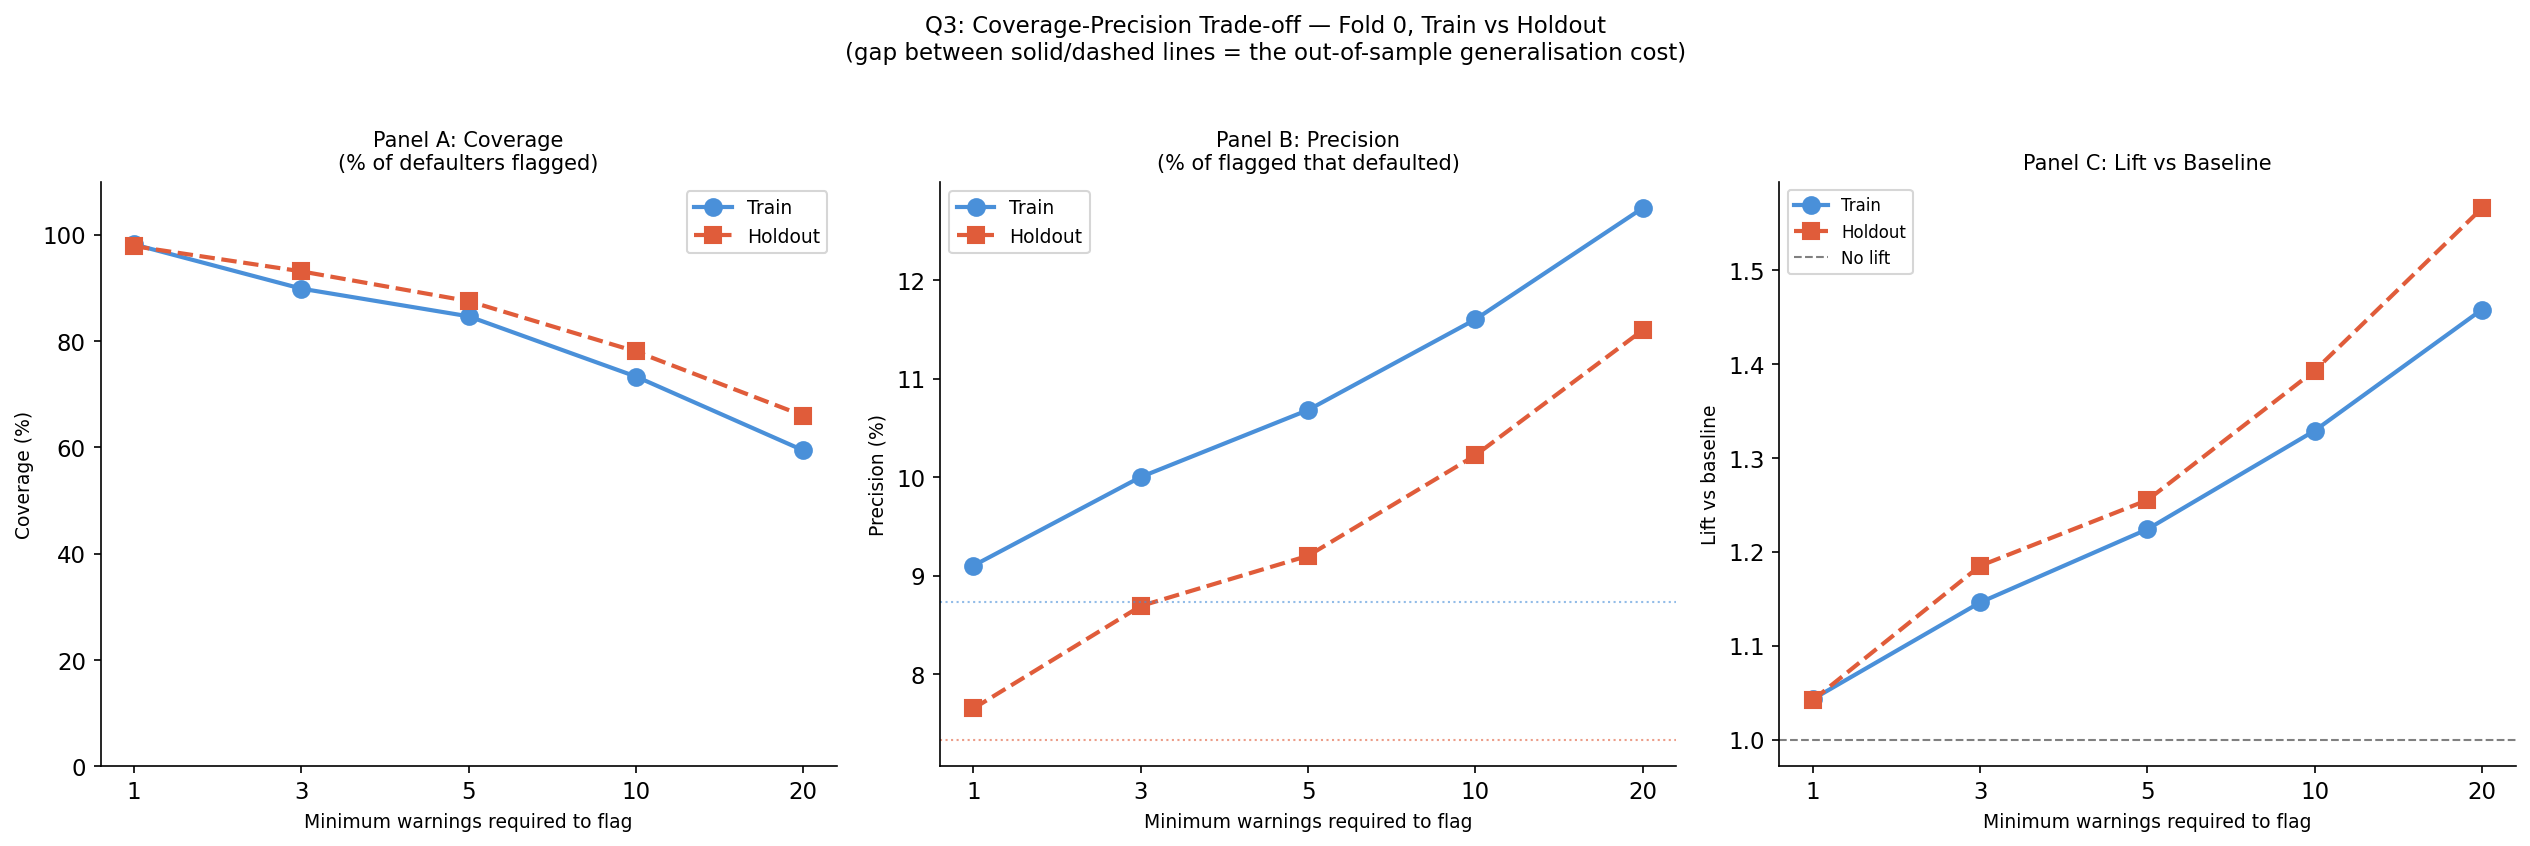

Figure saved: NB07_Q3_train_vs_holdout_fold0.png

Q1 + Q3 COMPLETE — FOLD 0
Review the train-vs-holdout gap in q1_df and q3_df above.
If this looks reasonable, we will proceed to Q2, Q4, Q5.


In [1]:
# ============================================================================
# NB07_simulation.ipynb  —  Nested CV Version, Step 1: fold 0 (Q1 + Q3 first)
#
# Study 2: Retrospective simulation of the two-layer early-warning system
# — OUT-OF-FOLD VALIDATION on fold 0's outer-holdout partition
#
# ----------------------------------------------------------------------------
# THIS IS THE CENTRAL PURPOSE OF THE ENTIRE NESTED-CV RESTRUCTURING
# ----------------------------------------------------------------------------
# NB01-NB06 discovered a 73-factor library (44 Layer 1 + 29 Layer 2) using
# ONLY fold 0's outer-TRAINING partition (N=12,537). This notebook applies
# that SAME, FIXED factor library — with thresholds frozen exactly as
# estimated from training data — to fold 0's outer-HOLDOUT partition
# (firms this factor library has never been fit to), and re-runs the
# paper's original five simulation questions (Q1-Q5) on that held-out set.
#
# CRITICAL DESIGN RULE: every threshold used below (L1's threshold_p33/
# threshold_p67, L2's cond*_p33/cond*_p67) comes from the TRAIN-derived
# NB06 output files. NONE of these thresholds are recomputed from the
# holdout data itself. If a threshold were recomputed here using
# `holdout_cohort[var].quantile(...)`, holdout information would leak into
# the very factor definitions being validated, defeating the purpose of
# the holdout split.
#
# A train-vs-holdout comparison table is added to each question, since
# the size of any train/holdout performance gap is the key evidence this
# whole exercise was designed to produce.
#
# Input  : data/processed/fold_0/upgrade_cohort_fold0.parquet
#           -> filtered to outer_split == "holdout"  [NEW — was "train" in
#              spirit for NB01-06; this is the FIRST notebook to touch
#              holdout data in this fold's pipeline]
#          results/tables/NB06_L1_single_factors_fold0.csv
#          results/tables/NB06_L2_composite_factors_fold0.csv
#          (for the train-side comparison columns:)
#          results/tables/NB07_01_firm_level_warnings_fold0_TRAIN.csv
#           -> produced by this same notebook's train-side pass, saved
#              under a distinct filename to avoid confusion with the
#              holdout-side outputs
# Outputs:
#   results/tables/NB07_01_firm_level_warnings_fold0_HOLDOUT.csv
#   results/tables/NB07_01_firm_level_warnings_fold0_TRAIN.csv
#   results/tables/NB07_Q1_warning_count_vs_default_fold0.csv
#     (contains both train and holdout columns side by side)
#   results/tables/NB07_Q3_coverage_analysis_fold0.csv
#     (contains both train and holdout columns side by side)
#   results/figures/NB07_Q1_train_vs_holdout_fold0.png
#   results/figures/NB07_Q3_train_vs_holdout_fold0.png
# ============================================================================

import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

warnings.filterwarnings("ignore")

plt.rcParams.update({
    "figure.dpi"       : 150,
    "axes.spines.top"  : False,
    "axes.spines.right": False,
    "font.size"        : 11,
    "font.family"      : "DejaVu Sans",
})

PROC_DIR  = "../data/processed/"
FIG_DIR   = "../results/figures/"
TABLE_DIR = "../results/tables/"

os.makedirs(FIG_DIR,   exist_ok=True)
os.makedirs(TABLE_DIR, exist_ok=True)

FOLD_ID = 0   # will become a loop variable in the next version


# ── Load fold 0 factor library (train-derived, fixed) ────────────────────────

L1_df = pd.read_csv(os.path.join(TABLE_DIR, f"NB06_L1_single_factors_fold{FOLD_ID}.csv"), index_col=0)
L2_df = pd.read_csv(os.path.join(TABLE_DIR, f"NB06_L2_composite_factors_fold{FOLD_ID}.csv"), index_col=0)

print(f"Loaded fold {FOLD_ID} factor library (frozen, train-derived):")
print(f"  L1 factors : {len(L1_df)}")
print(f"  L2 factors : {len(L2_df)}")


# ── Core function: apply the fixed factor library to ANY cohort partition ────
#
# This function is called TWICE below: once on the train partition (to
# reproduce the in-sample numbers NB06/NB07's original design would have
# produced) and once on the holdout partition (the actual out-of-fold
# validation). In both calls, the THRESHOLDS come from L1_df/L2_df — i.e.
# from training data — never recomputed from whichever partition is passed
# in as `cohort_part`.

def apply_factor_library(cohort_part, L1_df, L2_df, label):
    """
    Apply the fixed (train-derived) L1/L2 factor library to a cohort
    partition. Returns the partition with warning-count columns added.

    IMPORTANT: L1_df's threshold_p33/threshold_p67 and L2_df's
    cond*_p33/cond*_p67 are used AS-IS. No quantiles are recomputed from
    cohort_part here, regardless of whether cohort_part is the train or
    holdout partition.
    """
    cohort_part = cohort_part.copy()

    # -- Layer 1: apply each factor's train-derived tertile threshold --
    l1_matrix = pd.DataFrame(index=cohort_part.index)
    for fid, row in L1_df.iterrows():
        var       = row["variable"]
        direction = row["direction"]
        p33       = row["threshold_p33"]
        p67       = row["threshold_p67"]
        if var not in cohort_part.columns:
            continue
        if direction == "risk-reducing":
            l1_matrix[fid] = (cohort_part[var] <= p33).astype(int)
        else:
            l1_matrix[fid] = (cohort_part[var] >= p67).astype(int)

    # -- Layer 2: apply each rule's train-derived per-condition thresholds --
    l2_matrix = pd.DataFrame(index=cohort_part.index)
    for fid, rule_row in L2_df.iterrows():
        n_cond     = int(rule_row["n_conditions"])
        rule_match = pd.Series(True, index=cohort_part.index)
        valid_rule = True

        for c in range(1, n_cond + 1):
            var_name = rule_row.get(f"cond{c}_var")
            bin_val  = rule_row.get(f"cond{c}_bin")
            p33      = rule_row.get(f"cond{c}_p33")
            p67      = rule_row.get(f"cond{c}_p67")

            if pd.isna(var_name) or var_name not in cohort_part.columns:
                valid_rule = False
                break

            if bin_val == "LOW":
                cond = cohort_part[var_name] <= p33
            elif bin_val == "HIGH":
                cond = cohort_part[var_name] >= p67
            else:
                # MID or unrecognised — treat as always-false to be safe,
                # matching the original notebook's conservative behaviour
                # for unparseable bin values.
                cond = pd.Series(False, index=cohort_part.index)

            rule_match = rule_match & cond

        if not valid_rule:
            rule_match = pd.Series(False, index=cohort_part.index)

        l2_matrix[fid] = rule_match.astype(int)

    cohort_part["l1_count"]       = l1_matrix.sum(axis=1)
    cohort_part["l2_count"]       = l2_matrix.sum(axis=1)
    cohort_part["total_warnings"] = cohort_part["l1_count"] + cohort_part["l2_count"]
    cohort_part["any_warning"]    = (cohort_part["total_warnings"] >= 1).astype(int)

    print(f"\n  [{label}] N={len(cohort_part):,}  "
          f"L1/firm mean={cohort_part['l1_count'].mean():.1f}  "
          f"L2/firm mean={cohort_part['l2_count'].mean():.1f}  "
          f"Total/firm mean={cohort_part['total_warnings'].mean():.1f}")

    return cohort_part, l1_matrix, l2_matrix


# ── Load BOTH partitions of fold 0 ────────────────────────────────────────────

fold_cohort_path = os.path.join(PROC_DIR, f"fold_{FOLD_ID}", f"upgrade_cohort_fold{FOLD_ID}.parquet")
cohort_full_fold = pd.read_parquet(fold_cohort_path)

train_cohort   = cohort_full_fold[cohort_full_fold["outer_split"] == "train"].copy()
holdout_cohort = cohort_full_fold[cohort_full_fold["outer_split"] == "holdout"].copy()

print(f"\nFold {FOLD_ID} partitions:")
print(f"  Train   : {len(train_cohort):,} firms  |  "
      f"risky_upgrade rate: {train_cohort['is_risky'].mean()*100:.2f}%")
print(f"  Holdout : {len(holdout_cohort):,} firms  |  "
      f"risky_upgrade rate: {holdout_cohort['is_risky'].mean()*100:.2f}%")


# ── Apply the SAME frozen factor library to both partitions ──────────────────

print("\n[Setup] Applying fixed (train-derived) factor library to both partitions...")

train_cohort, l1_matrix_train, l2_matrix_train = apply_factor_library(
    train_cohort, L1_df, L2_df, label="TRAIN"
)
holdout_cohort, l1_matrix_holdout, l2_matrix_holdout = apply_factor_library(
    holdout_cohort, L1_df, L2_df, label="HOLDOUT"
)

BASELINE_DR_TRAIN   = train_cohort["default"].mean()
BASELINE_DR_HOLDOUT = holdout_cohort["default"].mean()
N_DEFAULT_TRAIN     = int(train_cohort["is_risky"].sum())
N_DEFAULT_HOLDOUT   = int(holdout_cohort["is_risky"].sum())

print(f"\n  Baseline DR — train   : {BASELINE_DR_TRAIN*100:.2f}%  (N_default={N_DEFAULT_TRAIN})")
print(f"  Baseline DR — holdout : {BASELINE_DR_HOLDOUT*100:.2f}%  (N_default={N_DEFAULT_HOLDOUT})")

firm_cols = ["group", "is_risky", "default", "from_grade", "to_grade",
             "transition", "year_horizon",
             "l1_count", "l2_count", "total_warnings", "any_warning"]

train_cohort[firm_cols].to_csv(
    os.path.join(TABLE_DIR, f"NB07_01_firm_level_warnings_fold{FOLD_ID}_TRAIN.csv")
)
holdout_cohort[firm_cols].to_csv(
    os.path.join(TABLE_DIR, f"NB07_01_firm_level_warnings_fold{FOLD_ID}_HOLDOUT.csv")
)
print(f"\n  Saved: NB07_01_firm_level_warnings_fold{FOLD_ID}_TRAIN.csv")
print(f"  Saved: NB07_01_firm_level_warnings_fold{FOLD_ID}_HOLDOUT.csv")


# ══════════════════════════════════════════════════════════════════════════════
# Q1: How many warning triggers indicate genuine risk? — TRAIN vs HOLDOUT
# ══════════════════════════════════════════════════════════════════════════════

print("\n" + "=" * 65)
print(f"Q1: Default rate by total warning count — Fold {FOLD_ID}, TRAIN vs HOLDOUT")
print("=" * 65)

brackets   = [0, 1, 3, 5, 10, 20, 50, 999]
labels_q1  = ["0", "1–2", "3–4", "5–9", "10–19", "20–49", "50+"]

def compute_q1(cohort_part, baseline_dr, label):
    cohort_part = cohort_part.copy()
    cohort_part["warn_bracket"] = pd.cut(
        cohort_part["total_warnings"], bins=brackets, labels=labels_q1, right=False
    )
    rows = []
    for bracket in labels_q1:
        sub = cohort_part[cohort_part["warn_bracket"] == bracket]
        if len(sub) == 0:
            rows.append({
                "warning_count_bracket": bracket,
                f"n_firms_{label}": 0, f"default_rate_{label}": np.nan,
                f"lift_{label}": np.nan,
            })
            continue
        dr = sub["default"].mean()
        rows.append({
            "warning_count_bracket": bracket,
            f"n_firms_{label}"     : len(sub),
            f"default_rate_{label}": round(dr, 4),
            f"lift_{label}"        : round(dr / baseline_dr, 3) if baseline_dr > 0 else np.nan,
        })
    return pd.DataFrame(rows).set_index("warning_count_bracket")

q1_train   = compute_q1(train_cohort,   BASELINE_DR_TRAIN,   "train")
q1_holdout = compute_q1(holdout_cohort, BASELINE_DR_HOLDOUT, "holdout")

q1_df = q1_train.join(q1_holdout)
q1_df.to_csv(os.path.join(TABLE_DIR, f"NB07_Q1_warning_count_vs_default_fold{FOLD_ID}.csv"))

print(q1_df.to_string())
print(f"\n  [Paper reference, full-sample run: 0 warnings -> 2.65% DR, "
      f"50+ warnings -> 12.97% DR, 4.90-fold differential]")


# Figure Q1 — train vs holdout side by side

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
ax_dr, ax_n = axes

x = np.arange(len(labels_q1))
w = 0.35

train_dr_vals   = q1_df["default_rate_train"].fillna(0).values * 100
holdout_dr_vals = q1_df["default_rate_holdout"].fillna(0).values * 100

ax_dr.bar(x - w/2, train_dr_vals, width=w, color="#4A90D9", alpha=0.85,
          edgecolor="white", label="Train (in-sample)")
ax_dr.bar(x + w/2, holdout_dr_vals, width=w, color="#E05C3A", alpha=0.85,
          edgecolor="white", label="Holdout (out-of-fold)")
ax_dr.axhline(BASELINE_DR_TRAIN * 100, color="#4A90D9", linestyle="--",
              linewidth=1, alpha=0.6)
ax_dr.axhline(BASELINE_DR_HOLDOUT * 100, color="#E05C3A", linestyle="--",
              linewidth=1, alpha=0.6)
ax_dr.set_xticks(x)
ax_dr.set_xticklabels(labels_q1, fontsize=9)
ax_dr.set_xlabel("Total warning count (L1 + L2)", fontsize=10)
ax_dr.set_ylabel("Default rate (%)", fontsize=10)
ax_dr.set_title(f"Panel A: Default Rate by Warning Count — Fold {FOLD_ID}\n"
                "Train (in-sample) vs Holdout (out-of-fold)", fontsize=10)
ax_dr.legend(fontsize=9)

train_n_vals   = q1_df["n_firms_train"].fillna(0).values
holdout_n_vals = q1_df["n_firms_holdout"].fillna(0).values

ax_n.bar(x - w/2, train_n_vals, width=w, color="#4A90D9", alpha=0.85,
         edgecolor="white", label="Train")
ax_n.bar(x + w/2, holdout_n_vals, width=w, color="#E05C3A", alpha=0.85,
         edgecolor="white", label="Holdout")
ax_n.set_xticks(x)
ax_n.set_xticklabels(labels_q1, fontsize=9)
ax_n.set_xlabel("Total warning count (L1 + L2)", fontsize=10)
ax_n.set_ylabel("Number of firms", fontsize=10)
ax_n.set_title("Panel B: Number of Firms per Bracket", fontsize=10)
ax_n.legend(fontsize=9)

plt.suptitle(
    f"Q1: Does Warning Count Predict Default Risk? — Fold {FOLD_ID}\n"
    f"73 factors (44 L1 + 29 L2), fixed thresholds from train, applied to both partitions",
    fontsize=11, y=1.02,
)
plt.tight_layout()
plt.savefig(FIG_DIR + f"NB07_Q1_train_vs_holdout_fold{FOLD_ID}.png", bbox_inches="tight")
plt.show()
print(f"Figure saved: NB07_Q1_train_vs_holdout_fold{FOLD_ID}.png")


# ══════════════════════════════════════════════════════════════════════════════
# Q3: Coverage-precision trade-off — TRAIN vs HOLDOUT
# ══════════════════════════════════════════════════════════════════════════════

print("\n" + "=" * 65)
print(f"Q3: Coverage-precision trade-off — Fold {FOLD_ID}, TRAIN vs HOLDOUT")
print("=" * 65)

thresholds = [1, 3, 5, 10, 20]

def compute_q3(cohort_part, baseline_dr, label):
    risky_part = cohort_part[cohort_part["is_risky"] == 1]
    rows = []
    for thresh in thresholds:
        flagged   = risky_part["total_warnings"] >= thresh
        n_flagged = flagged.sum()
        coverage  = n_flagged / len(risky_part) if len(risky_part) > 0 else np.nan
        flagged_all = cohort_part["total_warnings"] >= thresh
        warn_rate   = flagged_all.mean()
        precision   = (
            (flagged_all & cohort_part["is_risky"]).sum() / max(flagged_all.sum(), 1)
        )
        rows.append({
            "warning_threshold": thresh,
            f"n_flagged_{label}"   : int(n_flagged),
            f"coverage_{label}"    : round(coverage, 4) if pd.notna(coverage) else np.nan,
            f"warn_rate_{label}"   : round(warn_rate, 4),
            f"precision_{label}"   : round(precision, 4),
            f"lift_{label}"        : round(precision / baseline_dr, 3) if baseline_dr > 0 else np.nan,
        })
    return pd.DataFrame(rows).set_index("warning_threshold")

q3_train   = compute_q3(train_cohort,   BASELINE_DR_TRAIN,   "train")
q3_holdout = compute_q3(holdout_cohort, BASELINE_DR_HOLDOUT, "holdout")

q3_df = q3_train.join(q3_holdout)
q3_df.to_csv(os.path.join(TABLE_DIR, f"NB07_Q3_coverage_analysis_fold{FOLD_ID}.csv"))

print(q3_df.to_string())
print(f"\n  [Paper reference, full-sample run: threshold>=1 -> 98.7% coverage, "
      f"8.58% precision; threshold>=20 -> 62.0% coverage, 11.60% precision]")


# Figure Q3 — train vs holdout side by side

fig, axes = plt.subplots(1, 3, figsize=(17, 5.5))
ax_cov, ax_prec, ax_lift = axes

thresh_labels = [str(t) for t in thresholds]

ax_cov.plot(thresh_labels, q3_df["coverage_train"] * 100, "o-",
            color="#4A90D9", linewidth=2, markersize=8, label="Train")
ax_cov.plot(thresh_labels, q3_df["coverage_holdout"] * 100, "s--",
            color="#E05C3A", linewidth=2, markersize=8, label="Holdout")
ax_cov.set_xlabel("Minimum warnings required to flag", fontsize=9)
ax_cov.set_ylabel("Coverage (%)", fontsize=9)
ax_cov.set_title("Panel A: Coverage\n(% of defaulters flagged)", fontsize=10)
ax_cov.set_ylim(0, 110)
ax_cov.legend(fontsize=9)

ax_prec.plot(thresh_labels, q3_df["precision_train"] * 100, "o-",
             color="#4A90D9", linewidth=2, markersize=8, label="Train")
ax_prec.plot(thresh_labels, q3_df["precision_holdout"] * 100, "s--",
             color="#E05C3A", linewidth=2, markersize=8, label="Holdout")
ax_prec.axhline(BASELINE_DR_TRAIN * 100, color="#4A90D9", linestyle=":",
                linewidth=1, alpha=0.6)
ax_prec.axhline(BASELINE_DR_HOLDOUT * 100, color="#E05C3A", linestyle=":",
                linewidth=1, alpha=0.6)
ax_prec.set_xlabel("Minimum warnings required to flag", fontsize=9)
ax_prec.set_ylabel("Precision (%)", fontsize=9)
ax_prec.set_title("Panel B: Precision\n(% of flagged that defaulted)", fontsize=10)
ax_prec.legend(fontsize=9)

ax_lift.plot(thresh_labels, q3_df["lift_train"], "o-",
             color="#4A90D9", linewidth=2, markersize=8, label="Train")
ax_lift.plot(thresh_labels, q3_df["lift_holdout"], "s--",
             color="#E05C3A", linewidth=2, markersize=8, label="Holdout")
ax_lift.axhline(1.0, color="grey", linestyle="--", linewidth=1, label="No lift")
ax_lift.set_xlabel("Minimum warnings required to flag", fontsize=9)
ax_lift.set_ylabel("Lift vs baseline", fontsize=9)
ax_lift.set_title("Panel C: Lift vs Baseline", fontsize=10)
ax_lift.legend(fontsize=8)

plt.suptitle(
    f"Q3: Coverage-Precision Trade-off — Fold {FOLD_ID}, Train vs Holdout\n"
    "(gap between solid/dashed lines = the out-of-sample generalisation cost)",
    fontsize=11, y=1.02,
)
plt.tight_layout()
plt.savefig(FIG_DIR + f"NB07_Q3_train_vs_holdout_fold{FOLD_ID}.png", bbox_inches="tight")
plt.show()
print(f"Figure saved: NB07_Q3_train_vs_holdout_fold{FOLD_ID}.png")


print("\n" + "=" * 65)
print(f"Q1 + Q3 COMPLETE — FOLD {FOLD_ID}")
print("=" * 65)
print("Review the train-vs-holdout gap in q1_df and q3_df above.")
print("If this looks reasonable, we will proceed to Q2, Q4, Q5.")


Q2: Per-factor hit rate — Fold 0, TRAIN vs HOLDOUT
Saved: ../results/tables/NB07_Q2_factor_hit_rates_fold0.csv

Top 20 factors by TRAIN hit rate (with holdout comparison):
           layer                  variable  n_triggered_train  hit_rate_train  n_triggered_holdout  hit_rate_holdout
factor_id                                                                                                           
L2-09          2   Attr35=LOW & Attr38=LOW               1630           0.183                  415             0.178
L2-20          2  Attr30=HIGH & Attr35=LOW               1851           0.172                  504             0.161
L2-15          2  Attr35=LOW & Attr52=HIGH               1687           0.168                  433             0.159
L2-29          2   Attr35=LOW & Attr63=LOW               1920           0.168                  502             0.167
L2-22          2   Attr35=LOW & Attr53=LOW               1802           0.165                  450             0.173
L2-13   

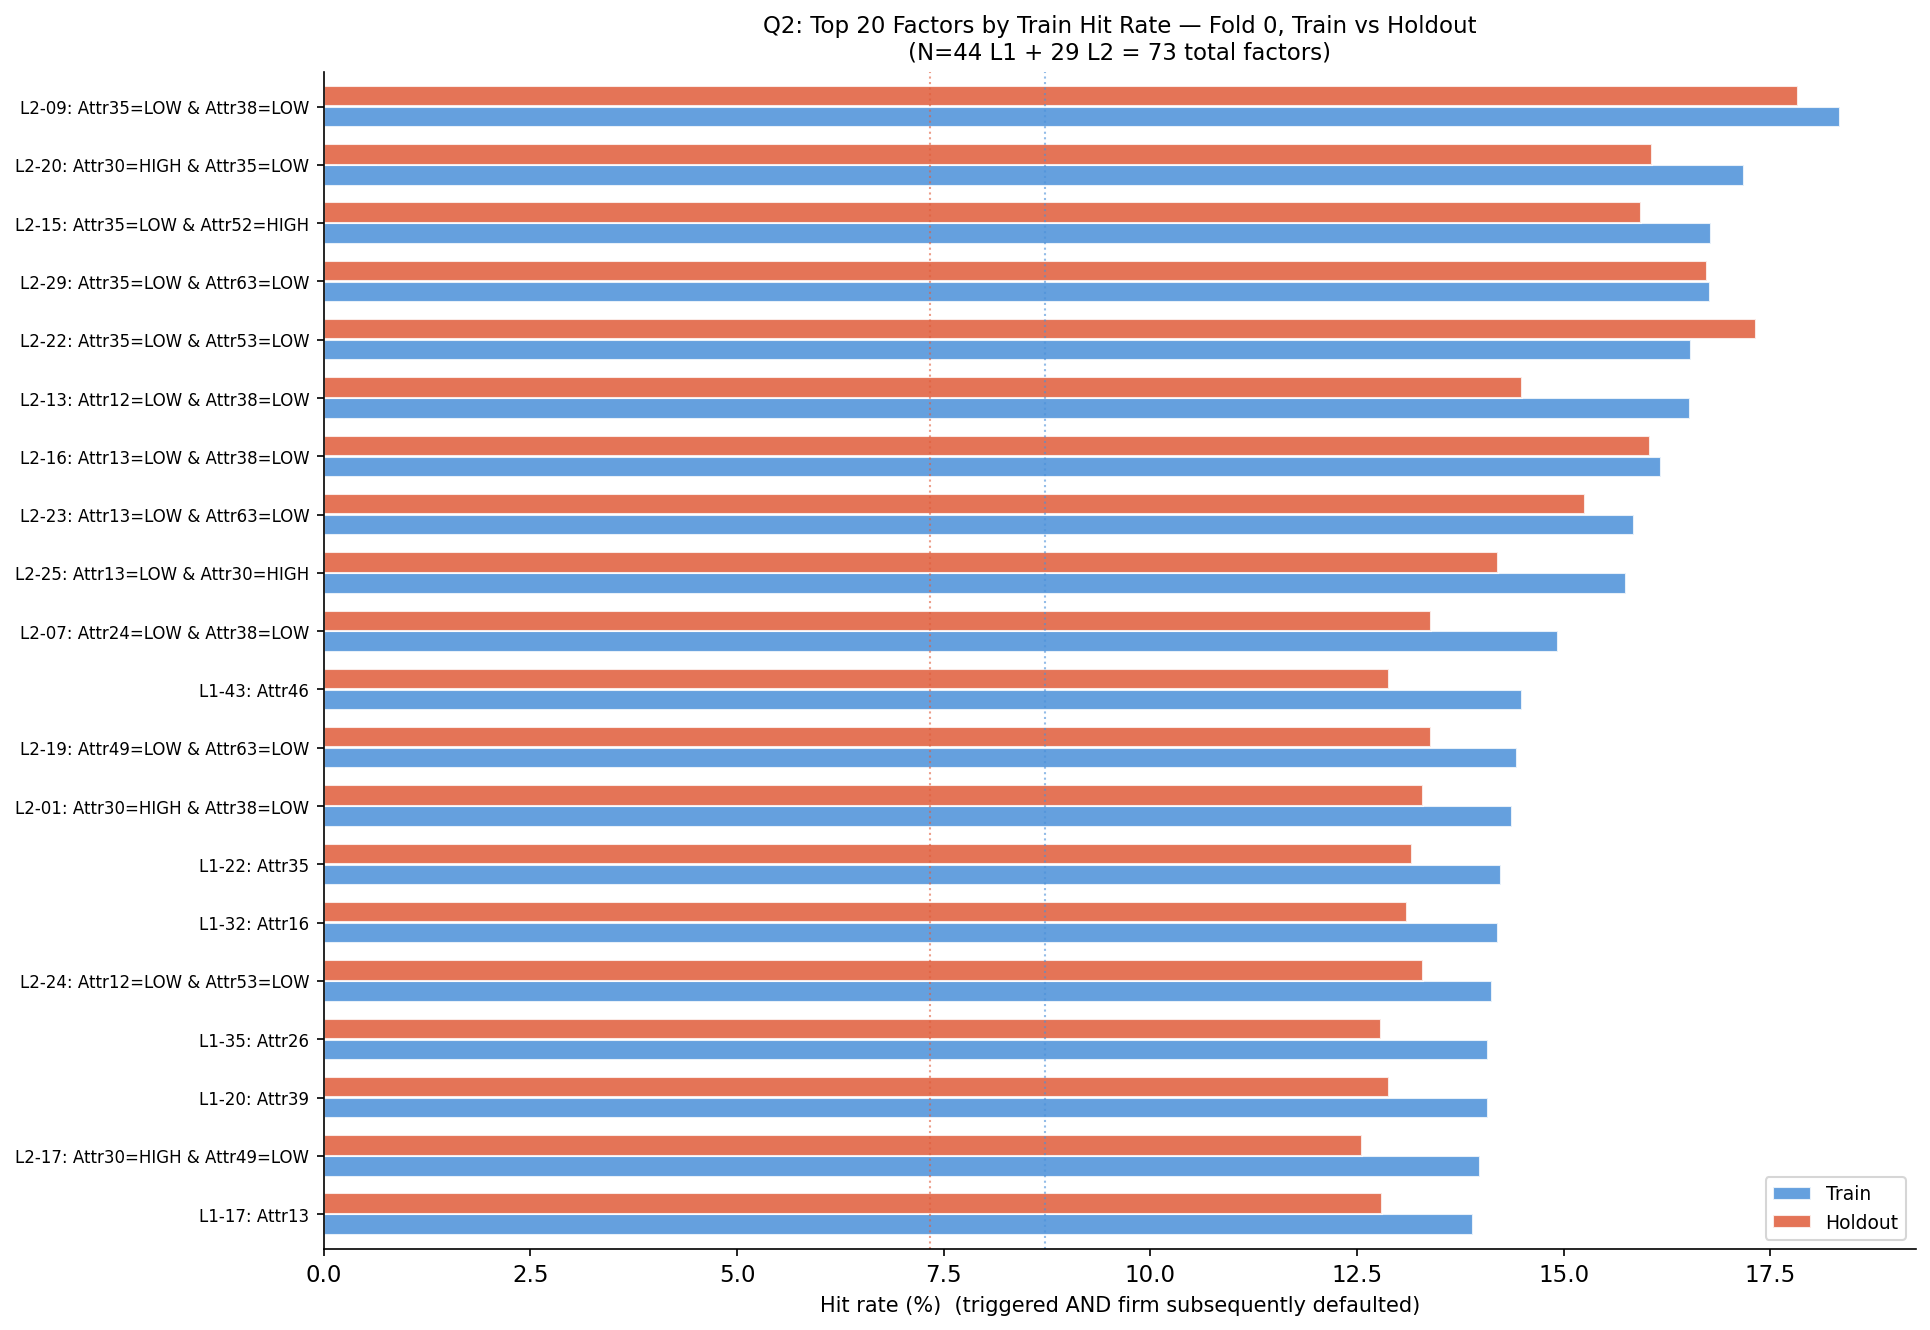

Figure saved: NB07_Q2_train_vs_holdout_fold0.png

Q2 COMPLETE — FOLD 0


In [2]:
# ══════════════════════════════════════════════════════════════════════════════
# Q2: Which individual factors were most accurate? — TRAIN vs HOLDOUT
# ══════════════════════════════════════════════════════════════════════════════

print("\n" + "=" * 65)
print(f"Q2: Per-factor hit rate — Fold {FOLD_ID}, TRAIN vs HOLDOUT")
print("=" * 65)

def compute_factor_hit_rates(cohort_part, l1_matrix, l2_matrix, L1_df, L2_df,
                              baseline_dr, n_default, label):
    """
    Compute hit rate (precision) and coverage for every L1 and L2 factor
    on the given cohort partition. l1_matrix/l2_matrix must already be
    computed against THIS partition (they are the per-firm 0/1 trigger
    indicators from apply_factor_library), so no threshold recomputation
    happens here — this function only aggregates outcomes.
    """
    rows = []

    for fid in l1_matrix.columns:
        triggered = l1_matrix[fid] == 1
        n_trig    = triggered.sum()
        if n_trig == 0:
            continue
        n_hit    = (triggered & cohort_part["is_risky"]).sum()
        hit_rate = n_hit / n_trig
        coverage = n_hit / n_default if n_default > 0 else np.nan
        var       = L1_df.loc[fid, "variable"]
        direction = L1_df.loc[fid, "direction"]
        rows.append({
            "factor_id"                : fid,
            "layer"                    : 1,
            "variable"                 : var,
            "direction"                : direction,
            f"n_triggered_{label}"     : int(n_trig),
            f"n_hit_{label}"           : int(n_hit),
            f"hit_rate_{label}"        : round(hit_rate, 4),
            f"lift_{label}"            : round(hit_rate / baseline_dr, 3) if baseline_dr > 0 else np.nan,
            f"coverage_{label}"        : round(coverage, 4) if pd.notna(coverage) else np.nan,
        })

    for fid in l2_matrix.columns:
        triggered = l2_matrix[fid] == 1
        n_trig    = triggered.sum()
        if n_trig == 0:
            continue
        n_hit    = (triggered & cohort_part["is_risky"]).sum()
        hit_rate = n_hit / n_trig
        coverage = n_hit / n_default if n_default > 0 else np.nan
        ant      = L2_df.loc[fid, "antecedents_str"]
        rows.append({
            "factor_id"                : fid,
            "layer"                    : 2,
            "variable"                 : ant[:60],
            "direction"                : "composite",
            f"n_triggered_{label}"     : int(n_trig),
            f"n_hit_{label}"           : int(n_hit),
            f"hit_rate_{label}"        : round(hit_rate, 4),
            f"lift_{label}"            : round(hit_rate / baseline_dr, 3) if baseline_dr > 0 else np.nan,
            f"coverage_{label}"        : round(coverage, 4) if pd.notna(coverage) else np.nan,
        })

    return pd.DataFrame(rows).set_index("factor_id")

perf_train = compute_factor_hit_rates(
    train_cohort, l1_matrix_train, l2_matrix_train, L1_df, L2_df,
    BASELINE_DR_TRAIN, N_DEFAULT_TRAIN, "train"
)
perf_holdout = compute_factor_hit_rates(
    holdout_cohort, l1_matrix_holdout, l2_matrix_holdout, L1_df, L2_df,
    BASELINE_DR_HOLDOUT, N_DEFAULT_HOLDOUT, "holdout"
)

# Merge on factor_id (keep layer/variable/direction from train side,
# they are identical across partitions since the factor library is fixed)
factor_perf_df = perf_train.join(
    perf_holdout.drop(columns=["layer", "variable", "direction"]),
    how="outer"
)
factor_perf_df = factor_perf_df.sort_values("hit_rate_train", ascending=False)

out_path = os.path.join(TABLE_DIR, f"NB07_Q2_factor_hit_rates_fold{FOLD_ID}.csv")
factor_perf_df.to_csv(out_path)
print(f"Saved: {out_path}")

print(f"\nTop 20 factors by TRAIN hit rate (with holdout comparison):")
print(factor_perf_df[["layer", "variable", "n_triggered_train", "hit_rate_train",
                       "n_triggered_holdout", "hit_rate_holdout"]]
      .head(20).round(3).to_string())

# [NEW] Rank-stability diagnostic: does a factor that was "top" in train
# remain reasonably strong in holdout, or does its hit rate collapse?
factor_perf_df["hit_rate_gap"] = (
    factor_perf_df["hit_rate_train"] - factor_perf_df["hit_rate_holdout"]
)
mean_gap = factor_perf_df["hit_rate_gap"].mean()
std_gap  = factor_perf_df["hit_rate_gap"].std()

print(f"\n  [Diagnostic] Train-holdout hit-rate gap across all {len(factor_perf_df)} factors:")
print(f"    Mean gap : {mean_gap:+.4f}")
print(f"    Std  gap : {std_gap:.4f}")
print(f"    (A small, roughly-zero-centred gap indicates factors generalise "
      f"consistently; a large positive mean gap would indicate overfitting "
      f"to train-specific patterns.)")


# Figure Q2 — top 20 factors, train vs holdout hit rate side by side

top20 = factor_perf_df.head(20).sort_values("hit_rate_train", ascending=True)
y_pos = np.arange(len(top20))

fig, ax = plt.subplots(figsize=(13, max(7, len(top20) * 0.45)))

ax.barh(y_pos - 0.18, top20["hit_rate_train"] * 100, height=0.35,
        color="#4A90D9", alpha=0.85, edgecolor="white", label="Train")
ax.barh(y_pos + 0.18, top20["hit_rate_holdout"].fillna(0) * 100, height=0.35,
        color="#E05C3A", alpha=0.85, edgecolor="white", label="Holdout")

ax.axvline(BASELINE_DR_TRAIN * 100, color="#4A90D9", linestyle=":",
           linewidth=1, alpha=0.6)
ax.axvline(BASELINE_DR_HOLDOUT * 100, color="#E05C3A", linestyle=":",
           linewidth=1, alpha=0.6)

ax.set_yticks(y_pos)
ax.set_yticklabels(
    [f"{fid}: {row['variable'][:35]}" for fid, row in top20.iterrows()],
    fontsize=8,
)
ax.set_ylim(-0.6, len(top20) - 0.4)
ax.set_xlabel("Hit rate (%)  (triggered AND firm subsequently defaulted)", fontsize=10)
ax.set_title(
    f"Q2: Top 20 Factors by Train Hit Rate — Fold {FOLD_ID}, Train vs Holdout\n"
    f"(N={len(L1_df)} L1 + {len(L2_df)} L2 = {len(L1_df)+len(L2_df)} total factors)",
    fontsize=11,
)
ax.legend(fontsize=9, loc="lower right")
plt.tight_layout()
plt.savefig(FIG_DIR + f"NB07_Q2_train_vs_holdout_fold{FOLD_ID}.png", bbox_inches="tight")
plt.show()
print(f"Figure saved: NB07_Q2_train_vs_holdout_fold{FOLD_ID}.png")

print("\n" + "=" * 65)
print(f"Q2 COMPLETE — FOLD {FOLD_ID}")
print("=" * 65)


Q4: Performance by grade transition and forecast horizon — Fold 0

  [Segment size check] Segments dropped for n < 20:
    Train   : 0 segment(s) dropped (none)
    Holdout : 0 segment(s) dropped (none)

Saved: ../results/tables/NB07_Q4_transition_performance_fold0.csv

Performance by grade transition (train vs holdout):
         n_train  baseline_dr_train  best_f1_train  n_holdout  baseline_dr_holdout  best_f1_holdout
segment                                                                                            
A→AA         984              0.018          0.105        248                0.008            0.044
BBB→A       1734              0.026          0.080        424                0.024            0.125
BB→BBB      2421              0.044          0.089        642                0.033            0.098
B→BB        3423              0.071          0.135        877                0.062            0.151
CCC→B       3975              0.171          0.297        972               

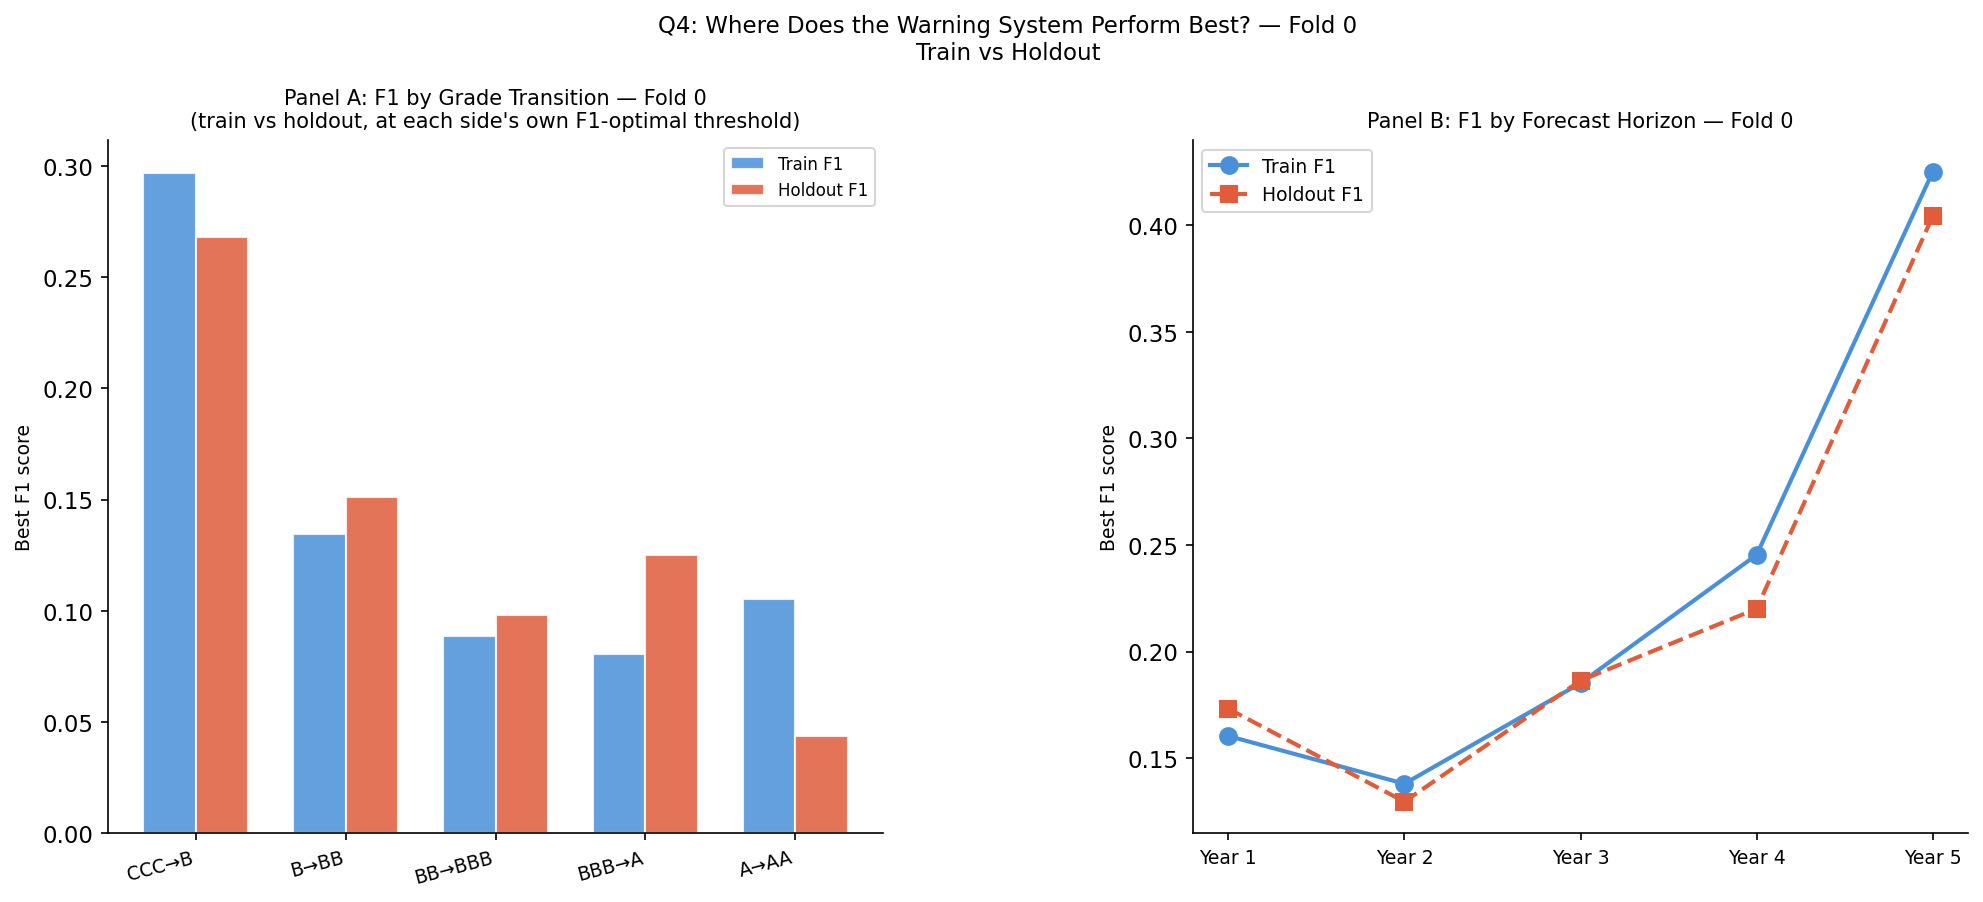

Figure saved: NB07_Q4_train_vs_holdout_fold0.png

Q4 COMPLETE — FOLD 0


In [3]:
# ══════════════════════════════════════════════════════════════════════════════
# Q4: Where does the system work best? — TRAIN vs HOLDOUT
# ══════════════════════════════════════════════════════════════════════════════

print("\n" + "=" * 65)
print(f"Q4: Performance by grade transition and forecast horizon — Fold {FOLD_ID}")
print("=" * 65)

MIN_SEGMENT_N = 20   # matches original notebook's threshold

def compute_optimal_f1(grp):
    """Grid-search over warning-count thresholds 1..29 for the F1-optimal
    cutoff within this segment. Returns (best_thresh, best_f1, precision,
    recall) at that threshold."""
    best_thresh, best_f1 = 1, 0
    best_prec, best_rec  = 0, 0
    for t in range(1, 30):
        flagged = grp["total_warnings"] >= t
        tp = (flagged & grp["is_risky"]).sum()
        fp = (flagged & ~grp["is_risky"]).sum()
        fn = (~flagged & grp["is_risky"]).sum()
        prec = tp / (tp + fp) if (tp + fp) > 0 else 0
        rec  = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1   = 2*prec*rec/(prec+rec) if (prec+rec) > 0 else 0
        if f1 > best_f1:
            best_f1, best_thresh = f1, t
            best_prec, best_rec  = prec, rec
    return best_thresh, best_f1, best_prec, best_rec


def compute_q4(cohort_part, label, min_n=MIN_SEGMENT_N):
    rows = []
    skipped_segments = []

    for trans, grp in cohort_part.groupby("transition"):
        if len(grp) < min_n:
            skipped_segments.append((trans, "transition", len(grp)))
            continue
        n, n_def, dr = len(grp), int(grp["is_risky"].sum()), grp["default"].mean()
        mean_warn = grp["total_warnings"].mean()
        thresh, f1, prec, rec = compute_optimal_f1(grp)
        rows.append({
            "segment": trans, "segment_type": "transition",
            f"n_{label}": n, f"n_defaulters_{label}": n_def,
            f"baseline_dr_{label}": round(dr, 4),
            f"mean_warnings_{label}": round(mean_warn, 2),
            f"optimal_threshold_{label}": thresh,
            f"best_f1_{label}": round(f1, 4),
            f"best_precision_{label}": round(prec, 4),
            f"best_recall_{label}": round(rec, 4),
        })

    for horizon, grp in cohort_part.groupby("year_horizon"):
        if len(grp) < min_n:
            skipped_segments.append((f"Year {horizon}", "horizon", len(grp)))
            continue
        n, n_def, dr = len(grp), int(grp["is_risky"].sum()), grp["default"].mean()
        mean_warn = grp["total_warnings"].mean()
        thresh, f1, prec, rec = compute_optimal_f1(grp)
        rows.append({
            "segment": f"Year {horizon}", "segment_type": "horizon",
            f"n_{label}": n, f"n_defaulters_{label}": n_def,
            f"baseline_dr_{label}": round(dr, 4),
            f"mean_warnings_{label}": round(mean_warn, 2),
            f"optimal_threshold_{label}": thresh,
            f"best_f1_{label}": round(f1, 4),
            f"best_precision_{label}": round(prec, 4),
            f"best_recall_{label}": round(rec, 4),
        })

    return pd.DataFrame(rows).set_index("segment"), skipped_segments


q4_train_df, skipped_train = compute_q4(train_cohort, "train")
q4_holdout_df, skipped_holdout = compute_q4(holdout_cohort, "holdout")

print(f"\n  [Segment size check] Segments dropped for n < {MIN_SEGMENT_N}:")
print(f"    Train   : {len(skipped_train)} segment(s) dropped "
      f"{[f'{s[0]} (n={s[2]})' for s in skipped_train] if skipped_train else '(none)'}")
print(f"    Holdout : {len(skipped_holdout)} segment(s) dropped "
      f"{[f'{s[0]} (n={s[2]})' for s in skipped_holdout] if skipped_holdout else '(none)'}")

# Merge — only segments present in BOTH partitions allow a direct comparison
q4_df = q4_train_df.drop(columns=["segment_type"]).join(
    q4_holdout_df.drop(columns=["segment_type"]), how="outer"
)
q4_df["segment_type"] = q4_train_df["segment_type"].combine_first(
    q4_holdout_df["segment_type"]
)

out_path = os.path.join(TABLE_DIR, f"NB07_Q4_transition_performance_fold{FOLD_ID}.csv")
q4_df.to_csv(out_path)
print(f"\nSaved: {out_path}")

trans_q4 = q4_df[q4_df["segment_type"] == "transition"]
horiz_q4 = q4_df[q4_df["segment_type"] == "horizon"]

print("\nPerformance by grade transition (train vs holdout):")
print(trans_q4[["n_train", "baseline_dr_train", "best_f1_train",
                 "n_holdout", "baseline_dr_holdout", "best_f1_holdout"]]
      .round(3).to_string())

print("\nPerformance by forecast horizon (train vs holdout):")
print(horiz_q4[["n_train", "baseline_dr_train", "best_f1_train",
                 "n_holdout", "baseline_dr_holdout", "best_f1_holdout"]]
      .round(3).to_string())


# Figure Q4 — train vs holdout, F1 by segment

if len(trans_q4) > 0:
    trans_sorted = trans_q4.sort_values("baseline_dr_train", ascending=False)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6), gridspec_kw={"wspace": 0.4})
    ax_tr, ax_ho = axes

    x = np.arange(len(trans_sorted))
    w = 0.35
    ax_tr.bar(x - w/2, trans_sorted["best_f1_train"].fillna(0),
              width=w, color="#4A90D9", alpha=0.85, edgecolor="white", label="Train F1")
    ax_tr.bar(x + w/2, trans_sorted["best_f1_holdout"].fillna(0),
              width=w, color="#E05C3A", alpha=0.85, edgecolor="white", label="Holdout F1")
    ax_tr.set_xticks(x)
    ax_tr.set_xticklabels(trans_sorted.index, fontsize=9, rotation=15, ha="right")
    ax_tr.set_ylabel("Best F1 score", fontsize=9)
    ax_tr.set_title(f"Panel A: F1 by Grade Transition — Fold {FOLD_ID}\n"
                    "(train vs holdout, at each side's own F1-optimal threshold)",
                    fontsize=10)
    ax_tr.legend(fontsize=8)

    if len(horiz_q4) > 0:
        horiz_sorted = horiz_q4.sort_index()
        x2 = np.arange(len(horiz_sorted))
        ax_ho.plot(x2, horiz_sorted["best_f1_train"], "o-",
                   color="#4A90D9", linewidth=2, markersize=8, label="Train F1")
        ax_ho.plot(x2, horiz_sorted["best_f1_holdout"], "s--",
                   color="#E05C3A", linewidth=2, markersize=8, label="Holdout F1")
        ax_ho.set_xticks(x2)
        ax_ho.set_xticklabels(horiz_sorted.index, fontsize=9)
        ax_ho.set_ylabel("Best F1 score", fontsize=9)
        ax_ho.set_title(f"Panel B: F1 by Forecast Horizon — Fold {FOLD_ID}",
                        fontsize=10)
        ax_ho.legend(fontsize=9)
    else:
        ax_ho.text(0.5, 0.5, "No horizon segments\nmet minimum size in both partitions",
                   ha="center", va="center", transform=ax_ho.transAxes)

    plt.suptitle(
        f"Q4: Where Does the Warning System Perform Best? — Fold {FOLD_ID}\n"
        "Train vs Holdout",
        fontsize=11, y=1.02,
    )
    plt.tight_layout()
    plt.savefig(FIG_DIR + f"NB07_Q4_train_vs_holdout_fold{FOLD_ID}.png", bbox_inches="tight")
    plt.show()
    print(f"Figure saved: NB07_Q4_train_vs_holdout_fold{FOLD_ID}.png")
else:
    print("  [WARNING] No transition segments met minimum size — skipping figure.")

print("\n" + "=" * 65)
print(f"Q4 COMPLETE — FOLD {FOLD_ID}")
print("=" * 65)


Q5: Default rate if warnings are ignored — Fold 0, TRAIN vs HOLDOUT
                 n_firms_train  n_defaulters_train  default_rate_train  lift_train  n_firms_holdout  n_defaulters_holdout  default_rate_holdout  lift_holdout
warning_level                                                                                                                                                
No warning                 732                  20              0.0273       0.313              194                     5                0.0258         0.351
Low (1–4)                 3132                 148              0.0473       0.542              763                    24                0.0315         0.429
Moderate (5–14)           2749                 219              0.0797       0.913              688                    36                0.0523         0.713
High (15–29)              2657                 241              0.0907       1.039              691                    63                0.09

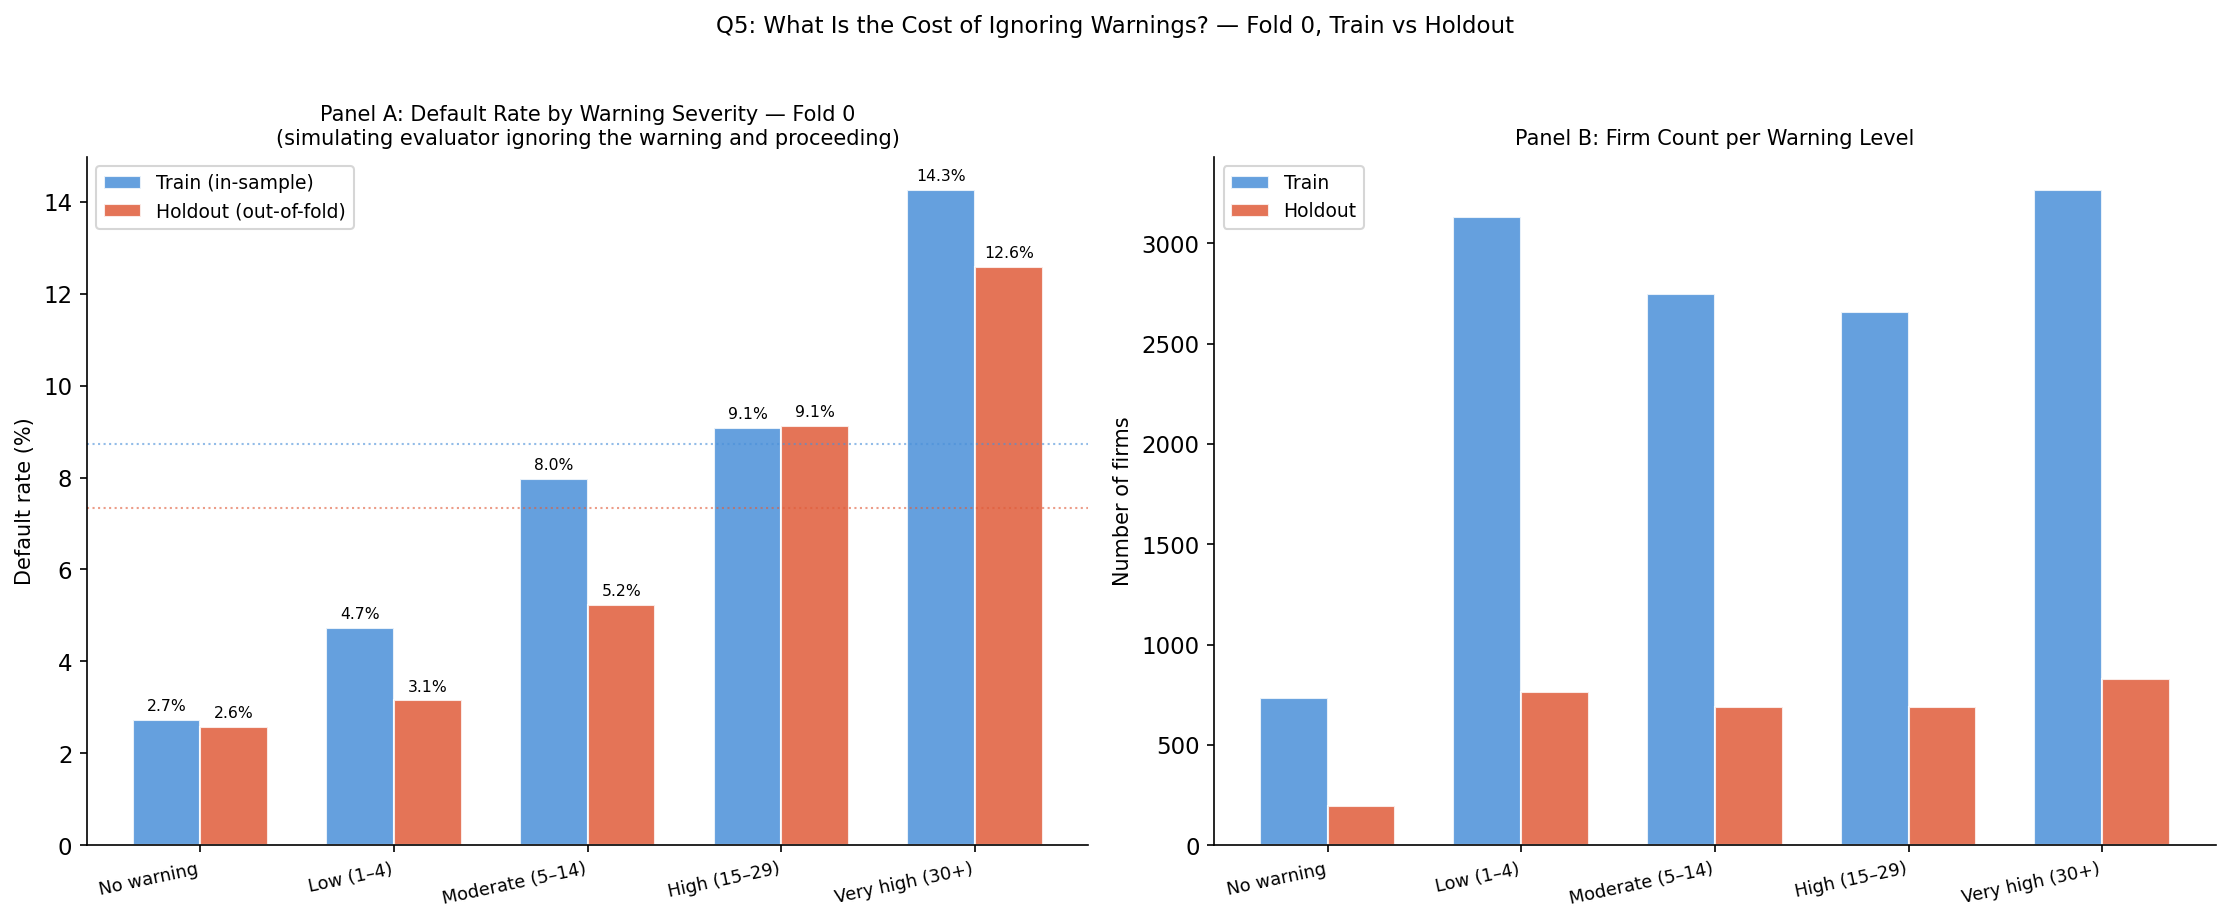

Figure saved: NB07_Q5_train_vs_holdout_fold0.png

NB07 SUMMARY — FOLD 0, TRAIN vs HOLDOUT

Cohort: train N=12,537 (DR=8.73%)  |  holdout N=3,163 (DR=7.33%)
Factor library: 44 L1 + 29 L2 = 73 total (train-derived, frozen, applied identically to both partitions)

Q1 — Warning count vs default rate:
  0 warnings  : train 2.73%  |  holdout 2.58%
  50+ warnings: train 17.10%  |  holdout 17.00%

Q2 — Factor hit-rate generalisation (train vs holdout):
  Mean gap: +0.0101  |  Std gap: 0.0062  (across all 73 factors)

Q3 — Coverage-precision at threshold>=1:
  Coverage: train 98.2%  |  holdout 97.8%
  Precision: train 9.10%  |  holdout 7.65%

Q4 — Best-performing grade transition:
  Train : CCC→B  F1=0.2968
  Holdout: CCC→B  F1=0.2682

Q5 — No warning vs Very high (30+):
  Train  : 2.73% -> 14.26%  (5.22x)
  Holdout: 2.58% -> 12.58%  (4.88x)

[Paper reference, full-sample run: 4.64-fold differential]

FOLD 0 COMPLETE. Next step -> replicate NB01-NB07 for folds 1-4,
then aggregate factor-stabili

In [4]:
# ══════════════════════════════════════════════════════════════════════════════
# Q5: What happens when warnings are ignored? — TRAIN vs HOLDOUT
# ══════════════════════════════════════════════════════════════════════════════

print("\n" + "=" * 65)
print(f"Q5: Default rate if warnings are ignored — Fold {FOLD_ID}, TRAIN vs HOLDOUT")
print("=" * 65)

def get_warn_levels(cohort_part):
    return {
        "No warning"        : cohort_part["total_warnings"] == 0,
        "Low (1–4)"         : cohort_part["total_warnings"].between(1, 4),
        "Moderate (5–14)"   : cohort_part["total_warnings"].between(5, 14),
        "High (15–29)"      : cohort_part["total_warnings"].between(15, 29),
        "Very high (30+)"   : cohort_part["total_warnings"] >= 30,
    }

def compute_q5(cohort_part, baseline_dr, label):
    levels = get_warn_levels(cohort_part)
    rows = []
    for level, mask in levels.items():
        sub   = cohort_part[mask]
        n     = len(sub)
        n_def = int(sub["is_risky"].sum())
        dr    = sub["default"].mean() if n > 0 else np.nan
        rows.append({
            "warning_level"        : level,
            f"n_firms_{label}"     : n,
            f"n_defaulters_{label}": n_def,
            f"default_rate_{label}": round(dr, 4) if pd.notna(dr) else np.nan,
            f"lift_{label}"        : round(dr / baseline_dr, 3) if (pd.notna(dr) and baseline_dr > 0) else np.nan,
        })
    return pd.DataFrame(rows).set_index("warning_level")

q5_train   = compute_q5(train_cohort,   BASELINE_DR_TRAIN,   "train")
q5_holdout = compute_q5(holdout_cohort, BASELINE_DR_HOLDOUT, "holdout")

q5_df = q5_train.join(q5_holdout)
out_path = os.path.join(TABLE_DIR, f"NB07_Q5_ignored_warning_effect_fold{FOLD_ID}.csv")
q5_df.to_csv(out_path)

print(q5_df.to_string())
print(f"\n  [Paper reference, full-sample run: No warning -> 2.65%, "
      f"Very high (30+) -> 12.30%, 4.64-fold differential]")


# Figure Q5 — train vs holdout side by side

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
ax_dr5, ax_n5 = axes

levels = q5_df.index.tolist()
x = np.arange(len(levels))
w = 0.35

train_dr   = q5_df["default_rate_train"].fillna(0).values * 100
holdout_dr = q5_df["default_rate_holdout"].fillna(0).values * 100

ax_dr5.bar(x - w/2, train_dr, width=w, color="#4A90D9", alpha=0.85,
           edgecolor="white", label="Train (in-sample)")
ax_dr5.bar(x + w/2, holdout_dr, width=w, color="#E05C3A", alpha=0.85,
           edgecolor="white", label="Holdout (out-of-fold)")
ax_dr5.axhline(BASELINE_DR_TRAIN * 100, color="#4A90D9", linestyle=":",
               linewidth=1, alpha=0.6)
ax_dr5.axhline(BASELINE_DR_HOLDOUT * 100, color="#E05C3A", linestyle=":",
               linewidth=1, alpha=0.6)

for i, (tv, hv) in enumerate(zip(train_dr, holdout_dr)):
    ax_dr5.text(i - w/2, tv + 0.2, f"{tv:.1f}%", ha="center", fontsize=7.5)
    ax_dr5.text(i + w/2, hv + 0.2, f"{hv:.1f}%", ha="center", fontsize=7.5)

ax_dr5.set_xticks(x)
ax_dr5.set_xticklabels(levels, fontsize=8.5, rotation=12, ha="right")
ax_dr5.set_ylabel("Default rate (%)", fontsize=10)
ax_dr5.set_title(
    f"Panel A: Default Rate by Warning Severity — Fold {FOLD_ID}\n"
    "(simulating evaluator ignoring the warning and proceeding)",
    fontsize=10,
)
ax_dr5.legend(fontsize=9)

train_n   = q5_df["n_firms_train"].fillna(0).values
holdout_n = q5_df["n_firms_holdout"].fillna(0).values

ax_n5.bar(x - w/2, train_n, width=w, color="#4A90D9", alpha=0.85,
          edgecolor="white", label="Train")
ax_n5.bar(x + w/2, holdout_n, width=w, color="#E05C3A", alpha=0.85,
          edgecolor="white", label="Holdout")
ax_n5.set_xticks(x)
ax_n5.set_xticklabels(levels, fontsize=8.5, rotation=12, ha="right")
ax_n5.set_ylabel("Number of firms", fontsize=10)
ax_n5.set_title("Panel B: Firm Count per Warning Level", fontsize=10)
ax_n5.legend(fontsize=9)

plt.suptitle(
    f"Q5: What Is the Cost of Ignoring Warnings? — Fold {FOLD_ID}, Train vs Holdout",
    fontsize=11, y=1.02,
)
plt.tight_layout()
plt.savefig(FIG_DIR + f"NB07_Q5_train_vs_holdout_fold{FOLD_ID}.png", bbox_inches="tight")
plt.show()
print(f"Figure saved: NB07_Q5_train_vs_holdout_fold{FOLD_ID}.png")


# ── Final fold-0 summary ───────────────────────────────────────────────────────

print("\n" + "=" * 65)
print(f"NB07 SUMMARY — FOLD {FOLD_ID}, TRAIN vs HOLDOUT")
print("=" * 65)

print(f"\nCohort: train N={len(train_cohort):,} (DR={BASELINE_DR_TRAIN*100:.2f}%)  |  "
      f"holdout N={len(holdout_cohort):,} (DR={BASELINE_DR_HOLDOUT*100:.2f}%)")
print(f"Factor library: {len(L1_df)} L1 + {len(L2_df)} L2 = {len(L1_df)+len(L2_df)} total "
      f"(train-derived, frozen, applied identically to both partitions)")

print(f"\nQ1 — Warning count vs default rate:")
print(f"  0 warnings  : train {q1_df.loc['0','default_rate_train']*100:.2f}%  |  "
      f"holdout {q1_df.loc['0','default_rate_holdout']*100:.2f}%")
print(f"  50+ warnings: train {q1_df.loc['50+','default_rate_train']*100:.2f}%  |  "
      f"holdout {q1_df.loc['50+','default_rate_holdout']*100:.2f}%")

print(f"\nQ2 — Factor hit-rate generalisation (train vs holdout):")
print(f"  Mean gap: {mean_gap:+.4f}  |  Std gap: {std_gap:.4f}  "
      f"(across all {len(factor_perf_df)} factors)")

print(f"\nQ3 — Coverage-precision at threshold>=1:")
print(f"  Coverage: train {q3_df.loc[1,'coverage_train']*100:.1f}%  |  "
      f"holdout {q3_df.loc[1,'coverage_holdout']*100:.1f}%")
print(f"  Precision: train {q3_df.loc[1,'precision_train']*100:.2f}%  |  "
      f"holdout {q3_df.loc[1,'precision_holdout']*100:.2f}%")

print(f"\nQ4 — Best-performing grade transition:")
best_trans_train = trans_q4["best_f1_train"].idxmax()
print(f"  Train : {best_trans_train}  F1={trans_q4.loc[best_trans_train,'best_f1_train']:.4f}")
best_trans_holdout = trans_q4["best_f1_holdout"].idxmax()
print(f"  Holdout: {best_trans_holdout}  F1={trans_q4.loc[best_trans_holdout,'best_f1_holdout']:.4f}")

print(f"\nQ5 — No warning vs Very high (30+):")
no_warn_train  = q5_df.loc["No warning", "default_rate_train"] * 100
high_warn_train = q5_df.loc["Very high (30+)", "default_rate_train"] * 100
no_warn_hold   = q5_df.loc["No warning", "default_rate_holdout"] * 100
high_warn_hold = q5_df.loc["Very high (30+)", "default_rate_holdout"] * 100
print(f"  Train  : {no_warn_train:.2f}% -> {high_warn_train:.2f}%  "
      f"({high_warn_train/no_warn_train:.2f}x)")
print(f"  Holdout: {no_warn_hold:.2f}% -> {high_warn_hold:.2f}%  "
      f"({high_warn_hold/no_warn_hold:.2f}x)")

print(f"\n[Paper reference, full-sample run: 4.64-fold differential]")
print(f"\nFOLD {FOLD_ID} COMPLETE. Next step -> replicate NB01-NB07 for folds 1-4,")
print(f"then aggregate factor-stability and performance-stability metrics across")
print(f"all 5 folds (this was the original goal established at the start of")
print(f"this restructuring effort).")